In [16]:
import sys
import os
import subprocess
import json
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, Image

sys.path.append(r'C:\Users\lucas\repositorios\mestrado_luedsbr\SRC')
# Caminho para o script Julia
script = "pareto_despacho_economico"    
script_julia = r"C:\Users\lucas\repositorios\mestrado_luedsbr\SRC\modelos_matematicos\\"+script+".jl"


from decisao_multicriterio.MCDA_DecisaoSubjetiva import *
from decisao_multicriterio.MCDA_DecisaoDados import *

Executando 'C:\Users\lucas\repositorios\mestrado_luedsbr\SRC\modelos_matematicos\\pareto_despacho_economico.jl' via subprocesso...
Execução concluída com sucesso:
Total de cenÃ¡rios a executar: 110
Executando cenÃ¡rio 1/110: w0_e10_c1
  Sucesso: Custo=1.67, EmissÃµes=0.01, Perdas=0.00672
Executando cenÃ¡rio 2/110: w0_e10_c2
  Sucesso: Custo=2.14, EmissÃµes=0.01, Perdas=0.00681
Executando cenÃ¡rio 3/110: w0_e10_c3
  Sucesso: Custo=1.86, EmissÃµes=0.01, Perdas=0.00677
Executando cenÃ¡rio 4/110: w0_e10_c4
  Sucesso: Custo=2.25, EmissÃµes=0.01, Perdas=0.00689
Executando cenÃ¡rio 5/110: w0_e10_c5
  Sucesso: Custo=1.87, EmissÃµes=0.01, Perdas=0.0068
Executando cenÃ¡rio 6/110: w0_e10_c6
  Sucesso: Custo=1.6, EmissÃµes=0.01, Perdas=0.00669
Executando cenÃ¡rio 7/110: w0_e10_c7
  Sucesso: Custo=1.36, EmissÃµes=0.01, Perdas=0.00627
Executando cenÃ¡rio 8/110: w0_e10_c8
  Sucesso: Custo=1.38, EmissÃµes=0.01, Perdas=0.00648
Executando cenÃ¡rio 9/110: w0_e10_c9
  Sucesso: Custo=1.36, EmissÃµes=0.01, 

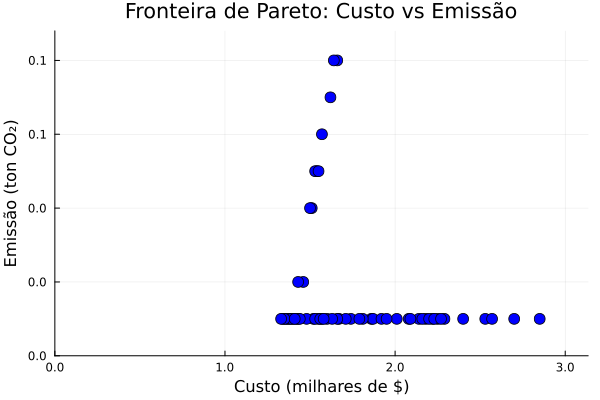

In [17]:
if not os.path.exists(script_julia):
    print(f"Arquivo Julia '{script_julia}' não encontrado.")
    sys.exit(1)
else:
    # Comando para executar
    comando = ["julia", script_julia]
    print(f"Executando '{script_julia}' via subprocesso...")

    # Executa e captura a saída
    try:
        resultado = subprocess.run(comando, capture_output=True, text=True, check=True)
        print("Execução concluída com sucesso:")
        print(resultado.stdout)
    except subprocess.CalledProcessError as e:
        print("Erro durante a execução do script Julia:")
        print(e.stderr)


Image(filename=r'C:\Users\lucas\repositorios\mestrado_luedsbr\relatorios\PARETO.png')

In [ ]:
# Caminho do arquivo
path = r"C:\Users\lucas\repositorios\mestrado_luedsbr\DATA\output\input_alternativas.json"
path = r"C:\Users\lucas\repositorios\mestrado_luedsbr\DATA\output\MCDA\input_alternativas_NOVO.json"
with open(path, "r") as f:
    DATA = json.load(f)

# Analise FluxPot e Preço

In [19]:
def analisa_cenario(data):
    # Convertendo para DataFrame
    resultados = data['resultados']

    # Preparando dados para geração por hora
    horas = [entry['hora'] for entry in resultados]
    geradores = ['G1', 'G2', 'G3', 'G4']
    geracao_por_hora = {gerador: [entry['geracao'][gerador] for entry in resultados] for gerador in geradores}
    dados_emissao = {gerador: [entry['emissao'][gerador] for entry in resultados] for gerador in geradores}
    emissoes_por_hora = [sum(valores) for valores in zip(dados_emissao['G1'],
                                                         dados_emissao['G2'],
                                                         dados_emissao['G3'],
                                                         dados_emissao['G4'],
                                                        )]
    
    # Criando figura com eixo secundário
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Plotando gráfico de barras empilhadas para geração
    bottom = [0] * len(horas)
    cores = ['red', 'orange', 'blue', 'green']

    for i, gerador in enumerate(geradores):
        ax1.bar(horas, geracao_por_hora[gerador], bottom=bottom, 
                label=gerador, color=cores[i], alpha=0.8, width=0.6)
        bottom = [bottom[j] + geracao_por_hora[gerador][j] for j in range(len(horas))]

   
    ax2 = ax1.twinx()
    ax2.plot(horas, emissoes_por_hora, color='grey', linewidth=3, 
            marker='o', markersize=6, label='Emissão', linestyle='dashed')

    # Configurações do gráfico
    ax1.set_ylim(0, 85)    # Geração de 0 a 100 MW
    ax2.set_ylim(0, 165)    # Emissão de 0 a 200 tCO
    ax1.set_xlabel('Hora do Dia', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Geração (MW)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Emissão (tCO₂)', fontsize=12, fontweight='bold', color='grey')
    ax2.tick_params(axis='y', labelcolor='#2C3E50')

    ax1.set_title(f'Geração por Fonte e Emissões - Alternativa C  \n'
                f'Peso Custo: {data["peso_custo"]}, Peso Emissão: {data["peso_emissao"]}', 
                fontsize=14, fontweight='bold', pad=20)

    ax1.set_xticks(horas)
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.legend(loc='upper left', bbox_to_anchor=(0, 1))
    ax2.legend(loc='upper right', bbox_to_anchor=(1, 1))

    plt.tight_layout()
    plt.show()

    # Exibindo totais do cenário
    print(f"=== RESUMO DO CENÁRIO {data['cenario_id']} ===")
    print(f"Custo Total: {data['custo_total']:.2f} USD")
    print(f"Emissão Total: {data['emissao_total']:.2f} tCO₂")
    print(f"Peso Custo: {data['peso_custo']}")
    print(f"Peso Emissão: {data['peso_emissao']}")

In [20]:
# alternativas_cen = [0,1,3,4,6,7]
# for cen in alternativas_cen:#range(0,11):
#     # Lendo o arquivo JSON
#     with open(f'/home/lucasedbraga/projetos/ufjf/mestrado_luedsbr/DATA/output/MCDA/fluxpot/output_fluxpot_cenario_{cen}.json', 'r') as file:
#         data = json.load(file)
    
#     #analisa_cenario(data)

# Modelos Subjetivos

In [21]:
# Matriz de Preferencias
matriz_preferencias_decisor = pd.DataFrame({
    'Custo Operacao': [1, 2],
    'Emissao ton CO2': [1/2, 1]
}, index=['Custo Operacao','Emissao ton CO2'])

In [22]:
ahp = AHP(arquivo_alternativas=DATA, matriz_preferencias_decisor=matriz_preferencias_decisor).rank_alternativas()

--------------------------------------------------------------------------------
Pesos dos critérios AHP:
Custo Operacao     0.667
Emissao ton CO2    0.333
dtype: float64

Ranking das Alternativas: - AHP 
   id_alternativa         descricao  Custo Operacao  Emissao ton CO2  Score
0               1  w_c=1.0, w_e=0.0         11622.0          2337.05  0.205
1               2  w_c=0.9, w_e=0.1         11945.4          2094.50  0.203
2               3  w_c=0.7, w_e=0.3         16855.8          1648.10  0.160
3               6  w_c=0.3, w_e=0.7         37309.2           668.58  0.148
4               5  w_c=0.4, w_e=0.6         35397.2           716.37  0.145
5               4  w_c=0.6, w_e=0.4         26503.2          1016.42  0.139


In [23]:
ahp_waspas = AHP_WASPAS(arquivo_alternativas=DATA, matriz_preferencias_decisor=matriz_preferencias_decisor).rank_alternativas()

--------------------------------------------------------------------------------
Pesos dos critérios AHP+WASPAS com lambda = 0.5:
Custo Operacao     0.667
Emissao ton CO2    0.333
dtype: float64

Ranking das Alternativas: - AHP+WASPAS 
   id_alternativa         descricao  Custo Operacao  Emissao ton CO2  Score
0               2  w_c=0.9, w_e=0.1         11945.4          2094.50  0.202
1               1  w_c=1.0, w_e=0.0         11622.0          2337.05  0.201
2               3  w_c=0.7, w_e=0.3         16855.8          1648.10  0.167
3               4  w_c=0.6, w_e=0.4         26503.2          1016.42  0.144
4               6  w_c=0.3, w_e=0.7         37309.2           668.58  0.143
5               5  w_c=0.4, w_e=0.6         35397.2           716.37  0.142


# Modelos Analíticos

In [24]:
ahp_gauss = AHP_Gaussiano(arquivo_alternativas=DATA).rank_alternativas()

--------------------------------------------------------------------------------
Pesos dos critérios (AHP-Gaussiano):
Custo Operacao     0.49
Emissao ton CO2    0.51
dtype: float64

Ranking das Alternativas: - (AHP-Gaussiano)
   id_alternativa         descricao  Custo Operacao  Emissao ton CO2  Score
0               6  w_c=0.3, w_e=0.7         37309.2           668.58  0.182
1               5  w_c=0.4, w_e=0.6         35397.2           716.37  0.175
2               2  w_c=0.9, w_e=0.1         11945.4          2094.50  0.173
3               1  w_c=1.0, w_e=0.0         11622.0          2337.05  0.171
4               4  w_c=0.6, w_e=0.4         26503.2          1016.42  0.151
5               3  w_c=0.7, w_e=0.3         16855.8          1648.10  0.148


In [25]:
ahp_gauss_waspas = AHP_Gaussiano_WASPAS(arquivo_alternativas=DATA).rank_alternativas()

--------------------------------------------------------------------------------
Pesos dos critérios AHP-Gaussiano+WASPAS com lambda = 0.5:
Custo Operacao     0.49
Emissao ton CO2    0.51
dtype: float64

Ranking das Alternativas: - AHP-Gaussiano+WASPAS
   id_alternativa         descricao  Custo Operacao  Emissao ton CO2  Score
0               6  w_c=0.3, w_e=0.7         37309.2           668.58  0.178
1               5  w_c=0.4, w_e=0.6         35397.2           716.37  0.173
2               2  w_c=0.9, w_e=0.1         11945.4          2094.50  0.171
3               1  w_c=1.0, w_e=0.0         11622.0          2337.05  0.167
4               4  w_c=0.6, w_e=0.4         26503.2          1016.42  0.157
5               3  w_c=0.7, w_e=0.3         16855.8          1648.10  0.154


In [26]:
lopcow_waspas = LOPCOW_WASPAS(arquivo_alternativas=DATA).rank_alternativas()

--------------------------------------------------------------------------------
Pesos dos critérios LOPCOW+WASPAS com lambda = 0.5:
Custo Operacao     0.48
Emissao ton CO2    0.52
dtype: float64

Ranking das Alternativas: - LOPCOW+WASPAS
   id_alternativa         descricao  Custo Operacao  Emissao ton CO2  Score
0               4  w_c=0.6, w_e=0.4         26503.2          1016.42  0.235
1               3  w_c=0.7, w_e=0.3         16855.8          1648.10  0.228
2               2  w_c=0.9, w_e=0.1         11945.4          2094.50  0.180
3               5  w_c=0.4, w_e=0.6         35397.2           716.37  0.161
4               6  w_c=0.3, w_e=0.7         37309.2           668.58  0.101
5               1  w_c=1.0, w_e=0.0         11622.0          2337.05  0.095


In [27]:
mpsi_waspas = MPSI_WASPAS(arquivo_alternativas=DATA).rank_alternativas()

--------------------------------------------------------------------------------
Pesos dos critérios MPSI+WASPAS com lambda = 0.5:
Custo Operacao     0.48
Emissao ton CO2    0.52
dtype: float64

Ranking das Alternativas: - MPSI+WASPAS 
   id_alternativa         descricao  Custo Operacao  Emissao ton CO2  Score
0               6  w_c=0.3, w_e=0.7         37309.2           668.58  0.180
1               5  w_c=0.4, w_e=0.6         35397.2           716.37  0.175
2               2  w_c=0.9, w_e=0.1         11945.4          2094.50  0.169
3               1  w_c=1.0, w_e=0.0         11622.0          2337.05  0.165
4               4  w_c=0.6, w_e=0.4         26503.2          1016.42  0.158
5               3  w_c=0.7, w_e=0.3         16855.8          1648.10  0.153


In [28]:
 # Gera os rankings
df_ahp = ahp.rename(columns={"Score": "AHP"})
df_ahp_waspas = ahp_waspas.rename(columns={"Score": "AHP+WASPAS"})
#df_waspas = waspas.rename(columns={"Score": "WASPAS"})
#df_wisp = wisp.rename(columns={"Score": "WISP"})
df_ahp_gauss = ahp_gauss.rename(columns={"Score": "AHP_Gaussiano"})
df_ahp_gauss_waspas = ahp_gauss.rename(columns={"Score": "AHP_Gaussiano+WASPAS"})
df_lopcow = lopcow_waspas.rename(columns={"Score": "LOPCOW+WASPAS"})
df_mpsi = mpsi_waspas.rename(columns={"Score": "MPSI+WASPAS"})

# Seleciona colunas-chave
base_cols = ["id_alternativa", "descricao"]

df_merged =  df_ahp[base_cols + ["AHP"]] \
    .merge(df_ahp_waspas[base_cols + ["AHP+WASPAS"]], on=base_cols, how="outer") \
    .merge(df_ahp_gauss[base_cols + ["AHP_Gaussiano"]], on=base_cols, how="outer") \
    .merge(df_ahp_gauss_waspas[base_cols + ["AHP_Gaussiano+WASPAS"]], on=base_cols, how="outer") \
    .merge(df_lopcow[base_cols + ["LOPCOW+WASPAS"]], on=base_cols, how="outer") \
    .merge(df_mpsi[base_cols + ["MPSI+WASPAS"]], on=base_cols, how="outer")       
    #.merge(df_wisp[base_cols + ["WISP"]], on=base_cols, how="outer")
     #.merge(df_ahp_waspas[base_cols + ["AHP_WASPAS"]], on=base_cols, how="outer") \

# Ordena por uma média dos scores
df_merged = df_merged.fillna(0)
df_merged["Score_Medio"] = df_merged[["AHP","AHP+WASPAS","AHP_Gaussiano","AHP_Gaussiano+WASPAS","LOPCOW+WASPAS", "MPSI+WASPAS"]].mean(axis=1)
df_merged = df_merged.sort_values(by="Score_Medio", ascending=False).reset_index(drop=True)

print('-'*90)
# Exporta para Excel
#df_merged.to_excel("/home/lucasedbraga/projetos/ufjf/mestrado_luedsbr/relatorios/ranking_comparativo_metodos.xlsx", index=False)
print(df_merged)

------------------------------------------------------------------------------------------
   id_alternativa         descricao    AHP  AHP+WASPAS  AHP_Gaussiano  \
0               2  w_c=0.9, w_e=0.1  0.203       0.202          0.173   
1               1  w_c=1.0, w_e=0.0  0.205       0.201          0.171   
2               3  w_c=0.7, w_e=0.3  0.160       0.167          0.148   
3               4  w_c=0.6, w_e=0.4  0.139       0.144          0.151   
4               5  w_c=0.4, w_e=0.6  0.145       0.142          0.175   
5               6  w_c=0.3, w_e=0.7  0.148       0.143          0.182   

   AHP_Gaussiano+WASPAS  LOPCOW+WASPAS  MPSI+WASPAS  Score_Medio  
0                 0.173          0.180        0.169     0.183333  
1                 0.171          0.095        0.165     0.168000  
2                 0.148          0.228        0.153     0.167333  
3                 0.151          0.235        0.158     0.163000  
4                 0.175          0.161        0.175     0.1621